In [2]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.8 MB/s eta 0:00:00


In [3]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

import evaluate
import numpy as np
import pandas as pd
from transformers import DataCollatorWithPadding

from datasets import load_dataset, DatasetDict, Dataset

In [4]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt


In [5]:
import os
os.environ["WANDB_DISABLED"] = "true"


In [6]:
from collections import Counter
import torch
from sklearn.utils.class_weight import compute_class_weight


In [9]:
id2labels = {0: 'sadness',
             1: 'joy',
             2: 'love',
             3: 'anger',
             4: 'fear',
             5: 'surprise'}
labels2id = {
        'sadness': 0,
        'joy' : 1,
        'love': 2,
        'anger':3,
        'fear' : 4,
        'surprise' : 5
    }

In [25]:

ds = load_dataset("dair-ai/emotion", "split")


In [13]:

import os
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)



In [27]:
train = ds['train']
train


Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

In [15]:
label_counts = Counter(train['label'])
print(label_counts)

Counter({1: 5362, 0: 4666, 3: 2159, 4: 1937, 2: 1304, 5: 572})


In [16]:
labels = np.array(train['label'])
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(labels),
                                     y=labels)

print("Class weights:", class_weights)


Class weights: [0.57151022 0.49732687 2.04498978 1.23513973 1.37669936 4.66200466]


In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights = torch.tensor(class_weights,
                             dtype=torch.float).to(device)

In [18]:
def compute_loss(model, inputs, return_outputs=False):
    labels = inputs.get("labels")
    outputs = model(**inputs)
    logits = outputs.get("logits")
    loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights)
    loss = loss_fct(logits.view(-1, model.config.num_labels),
                    labels.view(-1))
    return (loss, outputs) if return_outputs else loss

In [19]:
model_path = "distilbert/distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_path)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [20]:
model = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels = 6, id2label=id2labels, label2id = labels2id,)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [21]:
for name, param in model.named_parameters():
    param.requires_grad = True


In [28]:
def preprocess(ex):
    return tokenizer(ex['text'], truncation=True)

token_data =ds.map(preprocess, batched=True)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [29]:
token_data

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [30]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)  # we need to have same size example in a batch while training.

In [31]:
accuracy_metric = evaluate.load("accuracy")

In [32]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred.predictions, eval_pred.label_ids
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]}



In [33]:
lr = 2e-5
batch_size = 16
num_epochs = 10
weight_decay = 0.01
warmup_ratio = 0.1
max_length = 128


In [34]:
training_args = TrainingArguments(
    output_dir="distilbert-finetune",
    learning_rate=lr,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=num_epochs,
    weight_decay=weight_decay,
    warmup_ratio=warmup_ratio,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_dir="./logs",
    report_to="none",

)


In [35]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=token_data['train'],
    eval_dataset=token_data['validation'],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)



/tmp/ipython-input-3148696197.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [36]:
from transformers import TrainerCallback

class PrintMetricsCallback(TrainerCallback):
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics:
            print(f"\nEpoch {int(state.epoch)} | Eval Loss: {metrics['eval_loss']:.4f} | Eval Accuracy: {metrics.get('eval_accuracy', 0):.4f}")

trainer.add_callback(PrintMetricsCallback)

In [37]:
trainer.train()
trainer.save_model("DISTILLbert/final_model")



Epoch,Training Loss,Validation Loss,Accuracy
1,0.444200,0.253600,0.916000
2,0.181400,0.183626,0.932500
3,0.128900,0.172789,0.940000
4,0.107400,0.187148,0.936000
5,0.074800,0.244581,0.934500
6,0.058100,0.275511,0.934500
7,0.034900,0.333870,0.936500
8,0.021100,0.341046,0.938500
9,0.016700,0.361144,0.942000
10,0.019300,0.361385,0.939000



Epoch 1 | Eval Loss: 0.2536 | Eval Accuracy: 0.9160

Epoch 2 | Eval Loss: 0.1836 | Eval Accuracy: 0.9325

Epoch 3 | Eval Loss: 0.1728 | Eval Accuracy: 0.9400

Epoch 4 | Eval Loss: 0.1871 | Eval Accuracy: 0.9360

Epoch 5 | Eval Loss: 0.2446 | Eval Accuracy: 0.9345

Epoch 6 | Eval Loss: 0.2755 | Eval Accuracy: 0.9345

Epoch 7 | Eval Loss: 0.3339 | Eval Accuracy: 0.9365

Epoch 8 | Eval Loss: 0.3410 | Eval Accuracy: 0.9385

Epoch 9 | Eval Loss: 0.3611 | Eval Accuracy: 0.9420

Epoch 10 | Eval Loss: 0.3614 | Eval Accuracy: 0.9390



Classification Report:
              precision    recall  f1-score   support

           0      0.984     0.950     0.967       581
           1      0.938     0.961     0.950       695
           2      0.877     0.761     0.815       159
           3      0.918     0.931     0.924       275
           4      0.877     0.893     0.885       224
           5      0.683     0.848     0.757        66

    accuracy                          0.926      2000
   macro avg      0.879     0.891     0.883      2000
weighted avg      0.929     0.926     0.927      2000



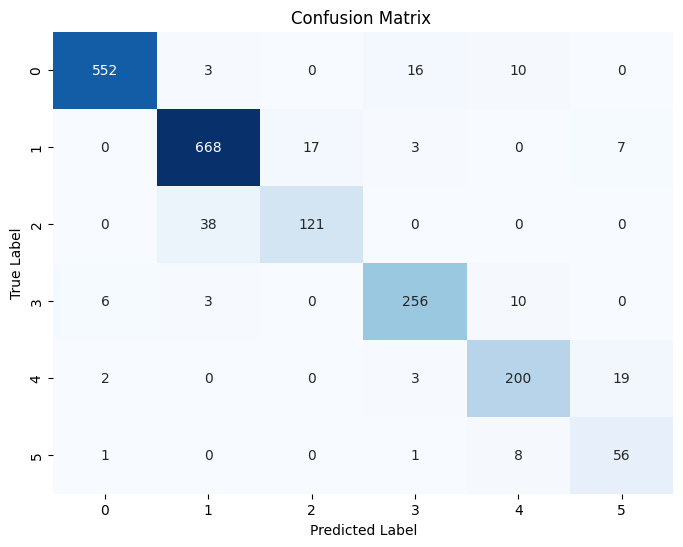

In [38]:
predictions = trainer.predict(token_data["test"])
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=3))
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix ")
plt.show()


In [40]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
save_path = "/content/drive/MyDrive/DISTILLbert/final_model"
trainer.save_model(save_path)
